In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)

## Q2 — Common slope across G1, G2, G3

In [2]:
df1 = pd.read_csv('homework_2.1.csv')
df1.head()

,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066


In [3]:
groups = ['G1', 'G2', 'G3']

for g in groups:
    s, i, *_ = stats.linregress(df1['time'], df1[g])
    print(f"{g}: slope={s:.6f}  intercept={i:.4f}")

# within-group demeaning to get a single common slope
y_dm = np.concatenate([df1[g].values - df1[g].mean() for g in groups])
t_dm = np.concatenate([df1['time'].values - df1['time'].mean() for _ in groups])

common_slope, *_ = stats.linregress(t_dm, y_dm)
print(f"common slope: {common_slope:.6f}")

G1: slope=0.008498  intercept=0.1042
G2: slope=0.007080  intercept=0.6855
G3: slope=0.011473  intercept=0.1475
common slope: 0.009017


## Q3–Q5 — Treatment effect and bootstrap

In [4]:
df2 = pd.read_csv('homework_2.2.csv')
print(df2.shape)
print(df2['X'].value_counts())
df2.head()

(10000, 3)
X
0    8028
1    1972
Name: count, dtype: int64


,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273


In [5]:
mean_treated   = df2.loc[df2['X'] == 1, 'Y'].mean()
mean_untreated = df2.loc[df2['X'] == 0, 'Y'].mean()
naive_effect = mean_treated - mean_untreated
print(f"naive effect: {naive_effect:.4f}")

naive effect: 2.9207


bootstrap variance: 0.03078


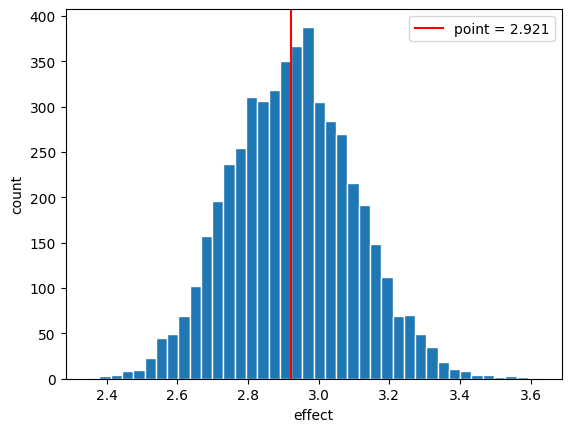

In [6]:
n_boot = 5000
n = len(df2)
rng = np.random.default_rng(0)

boot_effects = np.empty(n_boot)
for b in range(n_boot):
    s = df2.iloc[rng.integers(0, n, size=n)]
    boot_effects[b] = s.loc[s['X'] == 1, 'Y'].mean() - s.loc[s['X'] == 0, 'Y'].mean()

print(f"bootstrap variance: {boot_effects.var():.5f}")

plt.hist(boot_effects, bins=40, edgecolor='white')
plt.axvline(naive_effect, color='red', label=f'point = {naive_effect:.3f}')
plt.xlabel('effect'); plt.ylabel('count'); plt.legend(); plt.show()

OLS effect: 2.9207


bootstrap variance: 0.03137
bootstrap skewness: 0.10782


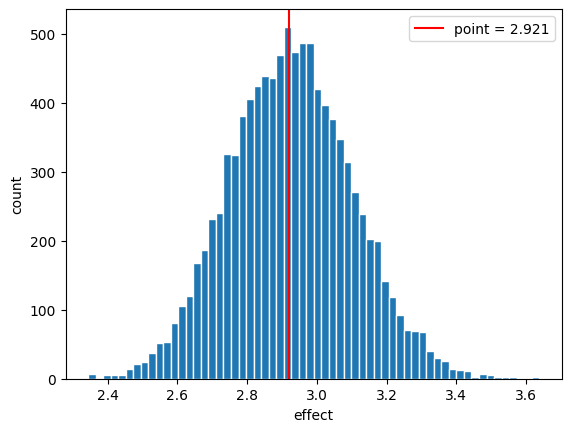

In [7]:
def ols_effect(sample):
    X = np.column_stack([np.ones(len(sample)), sample['X'].values])
    y = sample['Y'].values
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta[1]

point_beta = ols_effect(df2)
print(f"OLS effect: {point_beta:.4f}")

n_boot = 10000
rng = np.random.default_rng(0)
boot_betas = np.empty(n_boot)
for b in range(n_boot):
    boot_betas[b] = ols_effect(df2.iloc[rng.integers(0, n, size=n)])

print(f"bootstrap variance: {boot_betas.var():.5f}")
print(f"bootstrap skewness: {stats.skew(boot_betas):.5f}")

plt.hist(boot_betas, bins=60, edgecolor='white')
plt.axvline(point_beta, color='red', label=f'point = {point_beta:.3f}')
plt.xlabel('effect'); plt.ylabel('count'); plt.legend(); plt.show()